Aim:To check the stationarity, trend and seasonality of the given data.

In [ ]:
 #PROCEDURE:
# 1. DATA LOADING: Load 'daily-min-temperatures.csv' and 'daily-total-female-births.csv'
#    - Parse 'Date' column as datetime and set as index.
# 2. EXPLORATION: Plot line charts for both datasets to visually identify Trend and Seasonality.
# 3. STATIONARITY TESTING (ADF):
#    - H0: Series is non-stationary (Unit Root exists).
#    - Check: If p-value <= 0.05, the series is Stationary.
# 4. STATIONARITY TESTING (KPSS):
#    - H0: Series is stationary.
#    - Check: If p-value > 0.05, the series is Stationary.
# 5. DECOMPOSITION: Use seasonal_decompose to isolate:
#    - Trend: Long-term direction.
#    - Seasonality: Repeating patterns (e.g., yearly cycles in Temperature).
#    - Residuals: Random noise/irregularity.



In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('daily-total-female-births.csv',parse_dates=['Date'],index_col='Date')

In [20]:
df.head()

,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


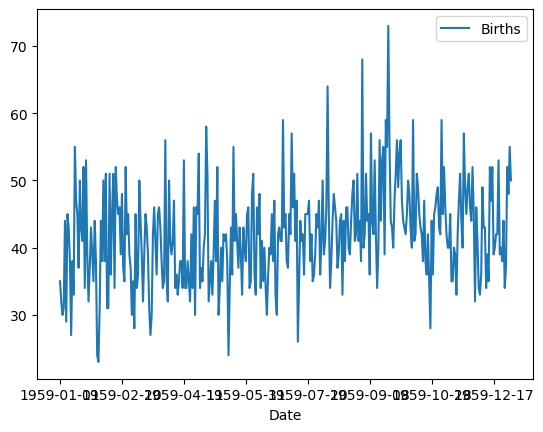

In [26]:
series=pd.read_csv('daily-total-female-births.csv',header=0,index_col=0)
series.plot()
plt.show()

In [47]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# 1. Load the dataset (use your specific file path)
df = pd.read_csv('daily-total-female-births.csv', parse_dates=['Date'], index_col='Date')

def perform_adf_test(series):
    # Perform the Augmented Dickey-Fuller test
    result = adfuller(series, autolag='AIC')
    
    print('ADF Test Results')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Number of Lags Used: {result[2]}')
    print(f'Number of Observations: {result[3]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
  
    if result[1] <= 0.05:
        print("\nResult: The series is stationary (Reject Null Hypothesis)")
    else:
        print("\nResult: The series is NOT stationary (Fail to Reject Null Hypothesis)")
        
# Run the test on the births column
perform_adf_test(df['Births'])



ADF Test Results
ADF Statistic: -4.8083
p-value: 0.0001
Number of Lags Used: 6
Number of Observations: 358
Critical Values:
   1%: -3.4487
   5%: -2.8696
   10%: -2.5711

Result: The series is stationary (Reject Null Hypothesis)


In [49]:
import pandas as pd
from statsmodels.tsa.stattools import kpss
import warnings
warnings.filterwarnings('ignore') # Hides interpolation warnings

# 1. Load the dataset
df = pd.read_csv('daily-total-female-births.csv', parse_dates=['Date'], index_col='Date')

def perform_kpss_test(series):
    # Perform KPSS test
    statistic, p_value, n_lags, critical_values = kpss(series, regression='c')
    
    print(' KPSS Test Results')
    print(f'KPSS Statistic: {statistic:.4f}')
    print(f'p-value: {p_value:.4f}')
    print(f'Number of Lags: {n_lags}')
    print('Critical Values:')
    for key, value in critical_values.items():
        print(f'   {key}: {value:.4f}')
    
    if p_value < 0.05:
        print("\nResult: The series is NOT stationary (Reject Null Hypothesis)")
    else:
        print("\nResult: The series is stationary (Fail to Reject Null Hypothesis)")

# Run the test on the births column
perform_kpss_test(df['Births'])


 KPSS Test Results
KPSS Statistic: 1.6130
p-value: 0.0100
Number of Lags: 7
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390

Result: The series is NOT stationary (Reject Null Hypothesis)


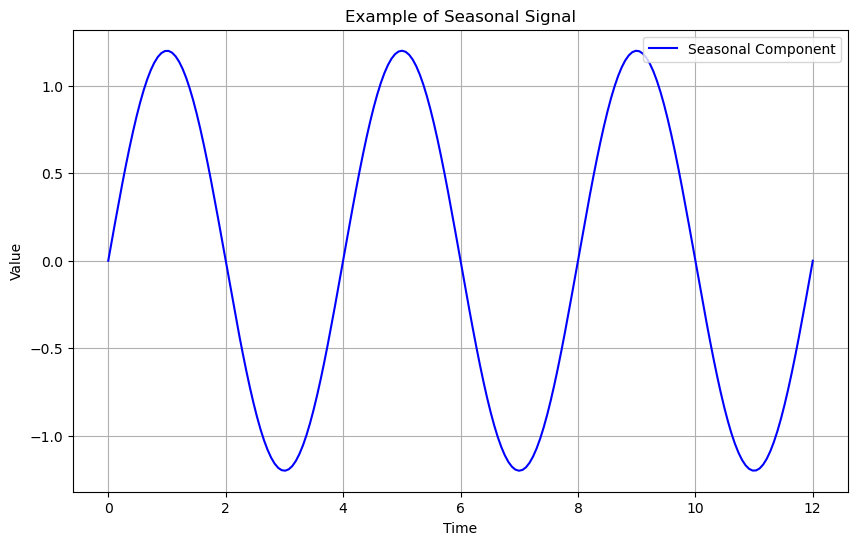

In [28]:
##seasonality
import numpy as np
#create a time axis
x_axis=np.linspace(0,12,num=200)
#generate sinosoidal seasonal graph
seasonality=1.2*np.sin(2*np.pi*x_axis/4)
# Plot the seasonal signal
plt.figure(figsize=(10, 6))
plt.plot(x_axis, seasonality, label="Seasonal Component", color="b")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Example of Seasonal Signal")
plt.grid(True)
plt.legend()
plt.show()

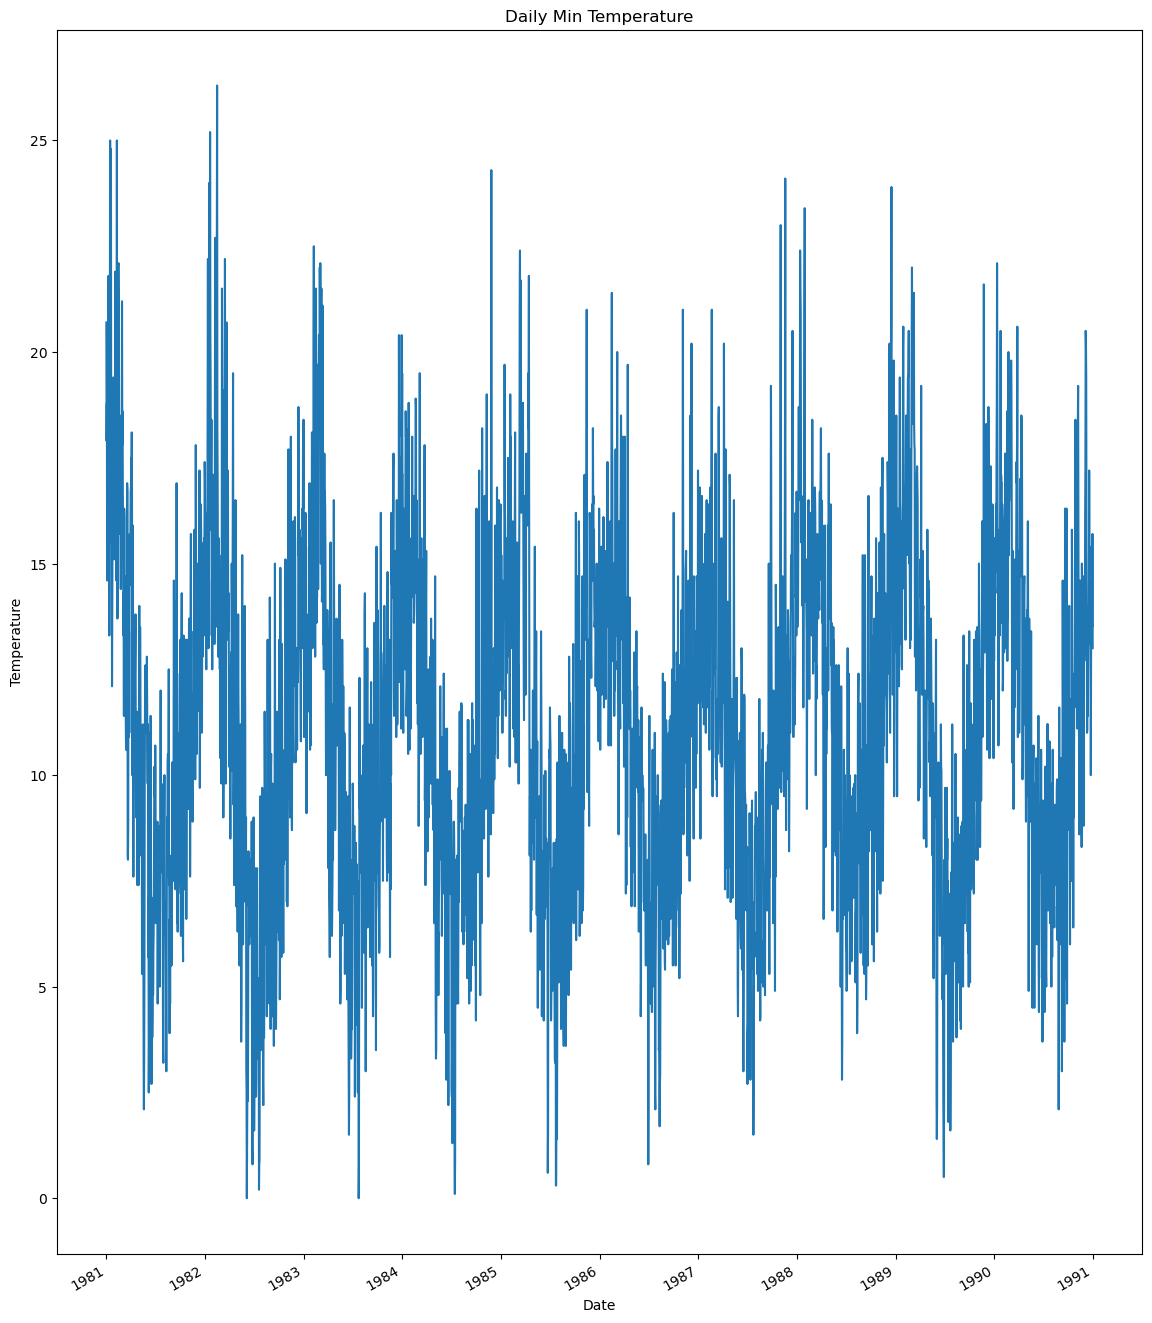

In [31]:
##Actual implementation(2ND DATASET)
df=pd.read_csv('daily-min-temp.csv',parse_dates=['Date'],index_col='Date')
df.plot(title='Daily Min Temperature',figsize=(14,18),legend=None)
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

In [40]:
##KPSS TEST

from statsmodels.tsa.stattools import kpss
def kpss_test(series):
    statistic,p_value,n_lag,critical_values=kpss(series)
    print(f'kpp statstic:{statistic:.4f}')
    print(f'p-value:{p_value:.4f}')
    print(f'Number of lags:{n_lag:.4f}')
    print('Critical Values:')
    for key, value in critical_values.items():
        print(f' {key}: {value:.4f}')
        print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')
kpss_test(df['Temp'])

kpp statstic:0.0557
p-value:0.1000
Number of lags:36.0000
Critical Values:
 10%: 0.3470
Result: The series is stationary
 5%: 0.4630
Result: The series is stationary
 2.5%: 0.5740
Result: The series is stationary
 1%: 0.7390
Result: The series is stationary


C:\Users\admin\AppData\Local\Temp\ipykernel_9148\659874553.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic,p_value,n_lag,critical_values=kpss(series)


In [44]:
##ADF TEST
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    # Perform Augmented Dickey-Fuller test
    result = adfuller(series, autolag='AIC')
    
    print('Augmented Dickey-Fuller Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Number of Lags Used: {result[2]}')
    print(f'Number of Observations Used: {result[3]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    
    # Interpretation: Null hypothesis is that the series is non-stationary
    if result[1] <= 0.05:
        print("Result: The series is stationary (Reject Null Hypothesis)")
    else:
        print("Result: The series is NOT stationary (Fail to Reject Null Hypothesis)")

# Run the test
adf_test(df['Temp'])


Augmented Dickey-Fuller Test:
ADF Statistic: -4.4448
p-value: 0.0002
Number of Lags Used: 20
Number of Observations Used: 3629
Critical Values:
   1%: -3.4322
   5%: -2.8623
   10%: -2.5672
Result: The series is stationary (Reject Null Hypothesis)


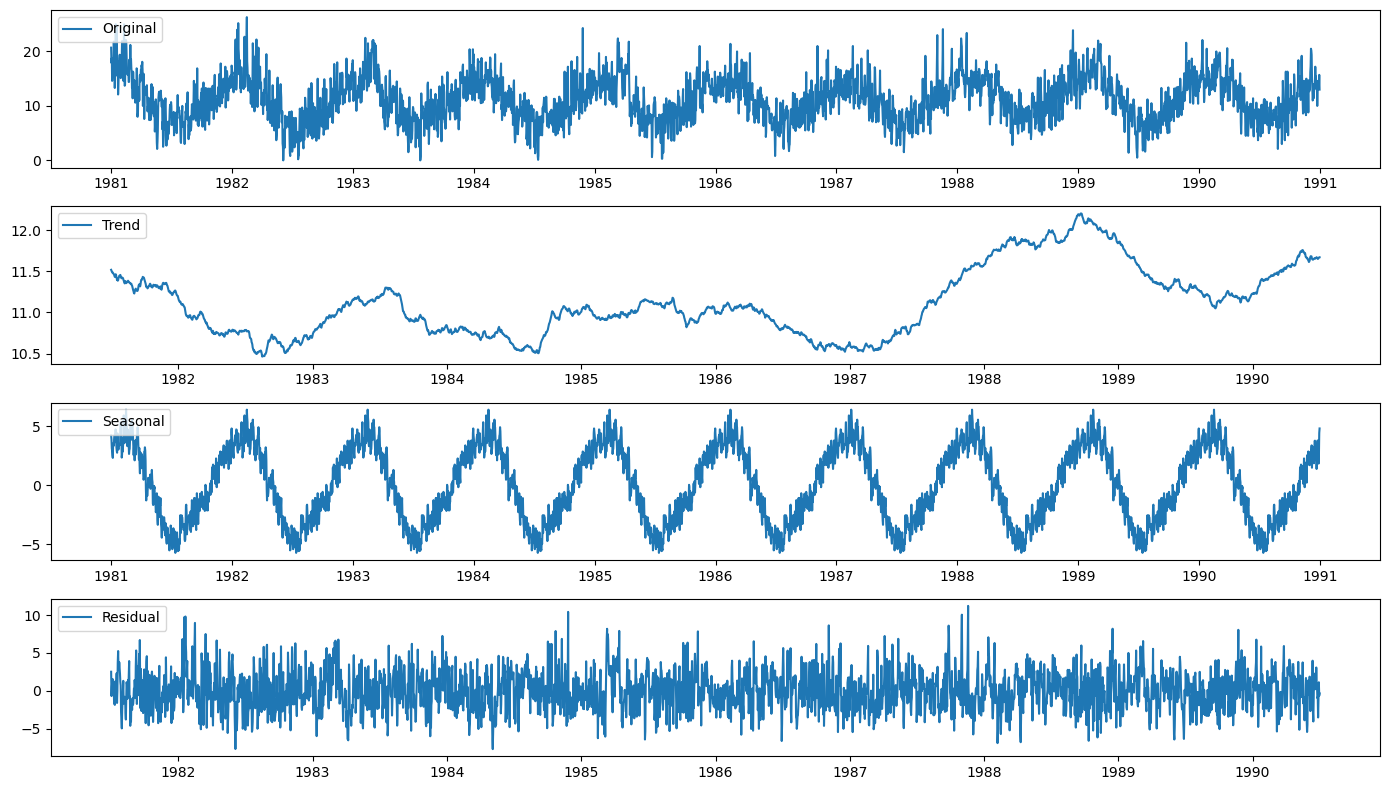

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
decomposition = seasonal_decompose(df['Temp'], model='additive', period=365)

# Plot the components
trend = decomposition. trend
seasonal = decomposition. seasonal
residual = decomposition.resid
plt.figure(figsize=(14, 8))
plt.subplot(411)
plt.plot(df['Temp'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='upper left')
plt.tight_layout ()
plt.show()

Result:
performed the stationarity, trend and seasonality of the given data